In [92]:
## importing packages
import numpy as np
import pandas as pd

In [93]:
## defining filepath constants
PATH_STATION_HOUR = "/content/station_hour.csv"
PATH_STATION_DAY = "/content/station_day.csv"
PATH_CITY_HOUR = "/content/city_hour.csv"
PATH_CITY_DAY = "/content/city_day.csv"
PATH_STATIONS = "/content/stations.csv"

# Get all unique station IDs from the stations metadata table
stationid_extract = pd.read_csv(PATH_STATIONS)
all_stations = stationid_extract['StationId'].tolist()
STATIONS = [all_stations]

In [94]:
df_station_hour = pd.read_csv(PATH_STATION_HOUR)
df_station_day = pd.read_csv(PATH_STATION_DAY)
df_city_hour = pd.read_csv(PATH_CITY_HOUR)
df_city_day = pd.read_csv(PATH_CITY_DAY)
df_stations = pd.read_csv(PATH_STATIONS)
print("Datasets successfully loaded!")

/tmp/ipykernel_1565/3202093550.py:1: DtypeWarning:

Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.



Datasets successfully loaded!


In [95]:
df_station_day.head(20)

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate
5,AP001,2017-11-29,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08,173.0,Moderate
6,AP001,2017-11-30,69.80,114.86,4.69,20.17,14.54,10.95,0.12,14.07,118.09,0.16,3.52,0.06,165.0,Moderate
7,AP001,2017-12-01,73.96,113.56,4.58,19.29,13.97,10.95,0.10,13.90,123.80,0.17,2.85,0.04,191.0,Moderate
8,AP001,2017-12-02,89.90,140.20,7.71,26.19,19.87,13.12,0.10,19.37,128.73,0.25,2.79,0.07,191.0,Moderate
9,AP001,2017-12-03,87.14,130.52,0.97,21.31,12.12,14.36,0.15,11.41,114.80,0.23,3.82,0.04,227.0,Poor


In [96]:
df_station_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   StationId   108035 non-null  object 
 1   Date        108035 non-null  object 
 2   PM2.5       86410 non-null   float64
 3   PM10        65329 non-null   float64
 4   NO          90929 non-null   float64
 5   NO2         91488 non-null   float64
 6   NOx         92535 non-null   float64
 7   NH3         59930 non-null   float64
 8   CO          95037 non-null   float64
 9   SO2         82831 non-null   float64
 10  O3          82467 non-null   float64
 11  Benzene     76580 non-null   float64
 12  Toluene     69333 non-null   float64
 13  Xylene      22898 non-null   float64
 14  AQI         87025 non-null   float64
 15  AQI_Bucket  87025 non-null   object 
dtypes: float64(13), object(3)
memory usage: 13.2+ MB


In [97]:
df_station_hour.head(20)

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.10,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.10,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.20,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.20,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.20,5.75,0.08,NaN,NaN
5,AP001,2017-11-24 22:00:00,69.25,108.25,0.70,18.47,10.38,13.80,0.1,9.25,91.10,0.20,5.02,0.00,NaN,NaN
6,AP001,2017-11-24 23:00:00,67.50,111.50,1.05,12.15,7.30,17.65,0.1,9.40,112.70,0.20,5.60,0.10,NaN,NaN
7,AP001,2017-11-25 00:00:00,68.00,111.00,1.25,14.12,8.50,20.28,0.1,8.90,116.12,0.20,5.55,0.05,NaN,NaN
8,AP001,2017-11-25 01:00:00,73.00,102.00,0.30,14.30,7.90,11.50,0.3,11.80,121.50,0.20,6.60,0.00,NaN,NaN
9,AP001,2017-11-25 02:00:00,81.00,123.00,0.80,24.85,13.88,10.28,0.1,11.62,83.80,0.23,6.77,0.10,NaN,NaN


In [98]:
df_stations.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [99]:
df_city_day.head(20)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


In [100]:
df_city_hour.head(20)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.00,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.00,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.00,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.00,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.00,0.0,NaN,NaN
5,Ahmedabad,2015-01-01 06:00:00,NaN,NaN,0.33,15.95,10.82,NaN,0.33,29.87,64.25,0.0,0.00,0.0,NaN,NaN
6,Ahmedabad,2015-01-01 07:00:00,NaN,NaN,0.45,15.94,12.47,NaN,0.45,27.41,191.96,0.0,0.00,0.0,NaN,NaN
7,Ahmedabad,2015-01-01 08:00:00,NaN,NaN,1.03,16.66,16.48,NaN,1.03,20.92,177.21,0.0,0.00,0.0,NaN,NaN
8,Ahmedabad,2015-01-01 09:00:00,NaN,NaN,1.47,16.25,18.02,NaN,1.47,16.45,122.08,0.0,0.00,0.0,NaN,NaN
9,Ahmedabad,2015-01-01 10:00:00,NaN,NaN,2.05,13.78,16.08,NaN,2.05,15.14,NaN,0.0,0.00,0.0,NaN,NaN


In [101]:
## importing data and subsetting the station
df = pd.read_csv(PATH_STATION_HOUR, parse_dates = ["Datetime"])
stations = pd.read_csv(PATH_STATIONS)

df.head()

/tmp/ipykernel_1565/2782744851.py:2: DtypeWarning:

Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.



,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [102]:
df = df.merge(stations, on = "StationId")
df.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [103]:
df

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.10,11.85,126.40,0.10,6.10,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.10,13.17,117.12,0.10,6.25,0.15,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.10,12.08,98.98,0.20,5.98,0.18,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.10,10.47,112.20,0.20,6.72,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.10,9.12,106.35,0.20,5.75,0.08,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2589078,WB013,2020-06-30 20:00:00,15.55,47.80,7.27,35.08,42.38,31.25,0.80,9.40,17.24,2.56,11.57,NaN,59.0,Satisfactory,"Victoria, Kolkata - WBPCB",Kolkata,West Bengal,Active
2589079,WB013,2020-06-30 21:00:00,15.23,42.30,6.10,26.78,32.85,30.66,0.56,4.91,17.46,3.49,12.29,NaN,59.0,Satisfactory,"Victoria, Kolkata - WBPCB",Kolkata,West Bengal,Active
2589080,WB013,2020-06-30 22:00:00,11.40,40.95,6.58,19.53,26.12,30.73,0.61,3.81,17.24,1.83,8.88,NaN,59.0,Satisfactory,"Victoria, Kolkata - WBPCB",Kolkata,West Bengal,Active
2589081,WB013,2020-06-30 23:00:00,9.25,34.33,9.17,21.85,31.00,29.61,0.65,3.44,12.74,1.40,8.43,NaN,59.0,Satisfactory,"Victoria, Kolkata - WBPCB",Kolkata,West Bengal,Active


In [104]:
print("City",df["City"].unique())
print("State",df["State"].unique())
print("Datetime",df["Datetime"].unique())

City ['Amaravati' 'Visakhapatnam' 'Guwahati' 'Patna' 'Chandigarh' 'Delhi'
 'Ahmedabad' 'Gurugram' 'Jorapokhar' 'Bengaluru' 'Ernakulam' 'Kochi'
 'Thiruvananthapuram' 'Mumbai' 'Shillong' 'Bhopal' 'Aizawl' 'Brajrajnagar'
 'Talcher' 'Amritsar' 'Jaipur' 'Hyderabad' 'Chennai' 'Coimbatore'
 'Lucknow' 'Kolkata']
State ['Andhra Pradesh' 'Assam' 'Bihar' 'Chandigarh' 'Delhi' 'Gujarat' 'Haryana'
 'Jharkhand' 'Karnataka' 'Kerala' 'Maharashtra' 'Meghalaya'
 'Madhya Pradesh' 'Mizoram' 'Odisha' 'Punjab' 'Rajasthan' 'Telangana'
 'Tamil Nadu' 'Uttar Pradesh' 'West Bengal']
Datetime <DatetimeArray>
['2017-11-24 17:00:00', '2017-11-24 18:00:00', '2017-11-24 19:00:00',
 '2017-11-24 20:00:00', '2017-11-24 21:00:00', '2017-11-24 22:00:00',
 '2017-11-24 23:00:00', '2017-11-25 00:00:00', '2017-11-25 01:00:00',
 '2017-11-25 02:00:00',
 ...
 '2015-04-04 01:00:00', '2015-04-04 02:00:00', '2015-04-04 03:00:00',
 '2015-04-04 04:00:00', '2015-04-04 05:00:00', '2015-04-04 06:00:00',
 '2015-04-04 07:00:00', '2015-04-0

# Weather Dataset

In [105]:
weather_data=pd.read_csv("/content/indian_cities_weather_dataset.csv")
weather_data.head()

,City,State,Datetime,Temperature_C,Relative_Humidity_pct,Wind_Speed_kmh
0,Amaravati,Andhra Pradesh,2015-01-01T00:00,23.0,77,8.4
1,Amaravati,Andhra Pradesh,2015-01-01T01:00,22.5,79,6.5
2,Amaravati,Andhra Pradesh,2015-01-01T02:00,22.7,80,8.4
3,Amaravati,Andhra Pradesh,2015-01-01T03:00,25.0,69,8.7
4,Amaravati,Andhra Pradesh,2015-01-01T04:00,26.9,62,11.1


In [106]:
import pandas as pd



weather_data['Datetime'] = pd.to_datetime(
    weather_data['Datetime'], errors='coerce'
)

# 3. Format it precisely to "YYYY-MM-DD HH:MM:SS" (e.g., 2020-06-30 23:00:00)
weather_data['Datetime'] = weather_data[
    'Datetime'
].dt.strftime('%Y-%m-%d %H:%M:%S')

# 4. Save back to the CSV file
weather_data.to_csv('weather_dataset_standalone.csv', index=False)

# Display a quick preview to verify the changes
print('Datetime formatting updated successfully!')
display(weather_data.head(10))

Datetime formatting updated successfully!


,City,State,Datetime,Temperature_C,Relative_Humidity_pct,Wind_Speed_kmh
0,Amaravati,Andhra Pradesh,2015-01-01 00:00:00,23.0,77,8.4
1,Amaravati,Andhra Pradesh,2015-01-01 01:00:00,22.5,79,6.5
2,Amaravati,Andhra Pradesh,2015-01-01 02:00:00,22.7,80,8.4
3,Amaravati,Andhra Pradesh,2015-01-01 03:00:00,25.0,69,8.7
4,Amaravati,Andhra Pradesh,2015-01-01 04:00:00,26.9,62,11.1
5,Amaravati,Andhra Pradesh,2015-01-01 05:00:00,28.6,56,8.8
6,Amaravati,Andhra Pradesh,2015-01-01 06:00:00,30.2,52,5.2
7,Amaravati,Andhra Pradesh,2015-01-01 07:00:00,30.5,51,6.3
8,Amaravati,Andhra Pradesh,2015-01-01 08:00:00,31.0,49,7.8
9,Amaravati,Andhra Pradesh,2015-01-01 09:00:00,31.0,48,8.4


In [107]:
import pandas as pd

# 1. Load the base station_hour data
if 'df_station_hour' not in globals():
    PATH_STATION_HOUR = "/content/station_hour.csv"
    df_station_hour = pd.read_csv(PATH_STATION_HOUR, parse_dates=["Datetime"], low_memory=False)

df = df_station_hour.copy()

# 2. Map Stations to Cities using df_stations metadata first
if 'df_stations' not in globals():
    df_stations = pd.read_csv("/content/stations.csv")

# Keep only StationId and City from metadata to avoid duplicate/extra columns
stations_map = df_stations[['StationId', 'City']]
df = pd.merge(df, stations_map, on='StationId', how='left')

# Ensure weather_data is loaded
if 'weather_data' not in globals():
    weather_data = pd.read_csv("/content/indian_cities_weather_dataset.csv")

# 3. Standardize column data types
df['Datetime'] = pd.to_datetime(df['Datetime'])
weather_data['Datetime'] = pd.to_datetime(weather_data['Datetime'])

# Ensure clean whitespace/character alignment in 'City'
df['City'] = df['City'].astype(str).str.strip()
weather_data['City'] = weather_data['City'].astype(str).str.strip()

# 4. Perform the left merge on BOTH 'City' and 'Datetime' to prevent row explosion
df_merged = pd.merge(
    df,
    weather_data,
    on=['City', 'Datetime'],
    how='left',
    suffixes=('', '_weather')
)

print("Successfully merged weather data based on City and Datetime!")
print("New merged dataset shape (should match original ~2.5M rows):", df_merged.shape)
display(df_merged.head())

Successfully merged weather data based on City and Datetime!
New merged dataset shape (should match original ~2.5M rows): (2589083, 21)


,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,City,State,Temperature_C,Relative_Humidity_pct,Wind_Speed_kmh
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,...,0.1,6.10,0.10,NaN,NaN,Amaravati,Andhra Pradesh,25.1,87.0,5.9
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,...,0.1,6.25,0.15,NaN,NaN,Amaravati,Andhra Pradesh,24.6,89.0,4.4
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,...,0.2,5.98,0.18,NaN,NaN,Amaravati,Andhra Pradesh,24.3,90.0,4.8
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,...,0.2,6.72,0.10,NaN,NaN,Amaravati,Andhra Pradesh,24.0,91.0,6.5
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,...,0.2,5.75,0.08,NaN,NaN,Amaravati,Andhra Pradesh,23.6,90.0,6.3


In [108]:
df_merged.shape

(2589083, 21)

In [109]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split # (Though we split chronologically below)

# 1. Make sure your data is sorted chronologically by station and time
df_merged = df_merged.sort_values(by=['StationId', 'Datetime']).reset_index(drop=True)

# 2. Define your Target Variable: Predicting future AQI (e.g., 24 hours ahead for "tomorrow")
# Shift AQI backward by 24 rows per station so the current row's features align with tomorrow's AQI
# Note: If your data has missing hours per station, group by 'StationId' first:
df_merged['Target_AQI_Tomorrow'] = df_merged.groupby('StationId')['AQI'].shift(-24)

# 3. Drop rows where the target is NaN (the last 24 hours of each station won't have a "tomorrow" label)
df_model = df_merged.dropna(subset=['Target_AQI_Tomorrow']).copy()


# Extract useful temporal features before dropping the Datetime column
df_model['Hour'] = df_model['Datetime'].dt.hour
df_model['DayOfWeek'] = df_model['Datetime'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df_model['Month'] = df_model['Datetime'].dt.month
df_model['DayOfYear'] = df_model['Datetime'].dt.dayofyear

# 4. Select your features (X) and target (y)
# Exclude text columns, identifiers, or direct leakage columns if needed
drop_cols = ['StationId', 'Datetime', 'City', 'State', 'AQI', 'AQI_Bucket', 'Target_AQI_Tomorrow','NO','NOx','NH3','Benzene','Toluene','Xylene']
feature_cols = [col for col in df_model.columns if col not in drop_cols]

X = df_model[feature_cols]
y = df_model['Target_AQI_Tomorrow']

# 5. Chronological Train-Test Split (e.g., 80% for training, last 20% for testing)
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

Training set shape: X_train (1614628, 13), y_train (1614628,)
Testing set shape: X_test (403658, 13), y_test (403658,)


# Train Dataset handling

In [110]:
summary=pd.DataFrame({
    'Total Rows':len(X_train),
    'Null Rows':X_train.isnull().sum(),
    'Filled Rows':X_train.notnull().sum(),
})
summary

,Total Rows,Null Rows,Filled Rows
PM2.5,1614628,126752,1487876
PM10,1614628,333880,1280748
NO2,1614628,85557,1529071
CO,1614628,122658,1491970
SO2,1614628,281252,1333376
O3,1614628,211072,1403556
Temperature_C,1614628,211315,1403313
Relative_Humidity_pct,1614628,211315,1403313
Wind_Speed_kmh,1614628,211315,1403313
Hour,1614628,0,1614628


# Missing value handling

In [111]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 1. Check current missing percentages
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100
print("Initial Missing Data Percentage:\n", missing_pct[missing_pct > 0])

# -------------------------------------------------------------
# RULE 1: Drop columns >40% missing, EXCEPT mandatory weather columns
# -------------------------------------------------------------
mandatory_weather_cols = ['Temperature_C', 'Relative_Humidity_pct', 'Wind_Speed_kmh']

# Find columns with >40% missing, but exclude weather features from being dropped
cols_to_drop = [col for col in missing_pct[missing_pct > 40].index if col not in mandatory_weather_cols]

satellite_data = X_train.drop(columns=cols_to_drop)
print(f"\nDropped columns (>40% missing): {cols_to_drop}")
print(f"Retained mandatory weather columns despite high missingness.")

# -------------------------------------------------------------
# SPECIAL HANDLING FOR WEATHER: Impute smoothly instead of dropping rows
# -------------------------------------------------------------
for col in mandatory_weather_cols:
    if col in satellite_data.columns:
        # Forward fill and backward fill per station/time continuity, then fallback to median
        satellite_data[col] = satellite_data[col].ffill().bfill()
        if satellite_data[col].isnull().sum() > 0:
            satellite_data[col] = satellite_data[col].fillna(satellite_data[col].median())

# -------------------------------------------------------------
# RULE 2: Rows with < 5% missing -> Drop Rows (for remaining columns)
# -------------------------------------------------------------
row_threshold = satellite_data.shape[1] - int(satellite_data.shape[1] * 0.05)
satellite_data = satellite_data.dropna(thresh=row_threshold)

# -------------------------------------------------------------
# RULE 3: Fill/Impute remaining missing values (5% to 40% range)
# -------------------------------------------------------------
numeric_cols = satellite_data.select_dtypes(include=['number']).columns
categorical_cols = satellite_data.select_dtypes(include=['object']).columns

if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    satellite_data[numeric_cols] = num_imputer.fit_transform(satellite_data[numeric_cols])

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    satellite_data[categorical_cols] = cat_imputer.fit_transform(satellite_data[categorical_cols])

# 4. Verify everything is clean
print(f"\nFinal Dataset Shape: {satellite_data.shape}")
print("Total remaining nulls:", satellite_data.isnull().sum().sum())

Initial Missing Data Percentage:
 PM2.5                     7.850229
PM10                     20.678447
NO2                       5.298868
CO                        7.596672
SO2                      17.418997
O3                       13.072485
Temperature_C            13.087535
Relative_Humidity_pct    13.087535
Wind_Speed_kmh           13.087535
dtype: float64

Dropped columns (>40% missing): []
Retained mandatory weather columns despite high missingness.

Final Dataset Shape: (904010, 13)
Total remaining nulls: 0


In [112]:
summary=pd.DataFrame({
    'Total Rows':len(satellite_data),
    'Null Rows':satellite_data.isnull().sum(),
    'Filled Rows':satellite_data.notnull().sum(),
})
summary

,Total Rows,Null Rows,Filled Rows
PM2.5,904010,0,904010
PM10,904010,0,904010
NO2,904010,0,904010
CO,904010,0,904010
SO2,904010,0,904010
O3,904010,0,904010
Temperature_C,904010,0,904010
Relative_Humidity_pct,904010,0,904010
Wind_Speed_kmh,904010,0,904010
Hour,904010,0,904010


In [113]:
import plotly.express as px
import pandas as pd

# Ensure the target series is aligned with our cleaned features
visual_df = satellite_data.copy()
visual_df['Target_AQI_Tomorrow'] = y_train.loc[visual_df.index]

# Sample a subset for smooth 3D rendering
sample_df = visual_df.sample(n=5000, random_state=42)

fig = px.scatter_3d(
    sample_df,
    x='PM2.5',
    y='Temperature_C',
    z='Wind_Speed_kmh',
    color='Target_AQI_Tomorrow',
    color_continuous_scale='Viridis',
    opacity=0.7,
    title="3D Interactive Scatter: PM2.5 vs Temperature vs Wind Speed (Colored by Target AQI)"
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

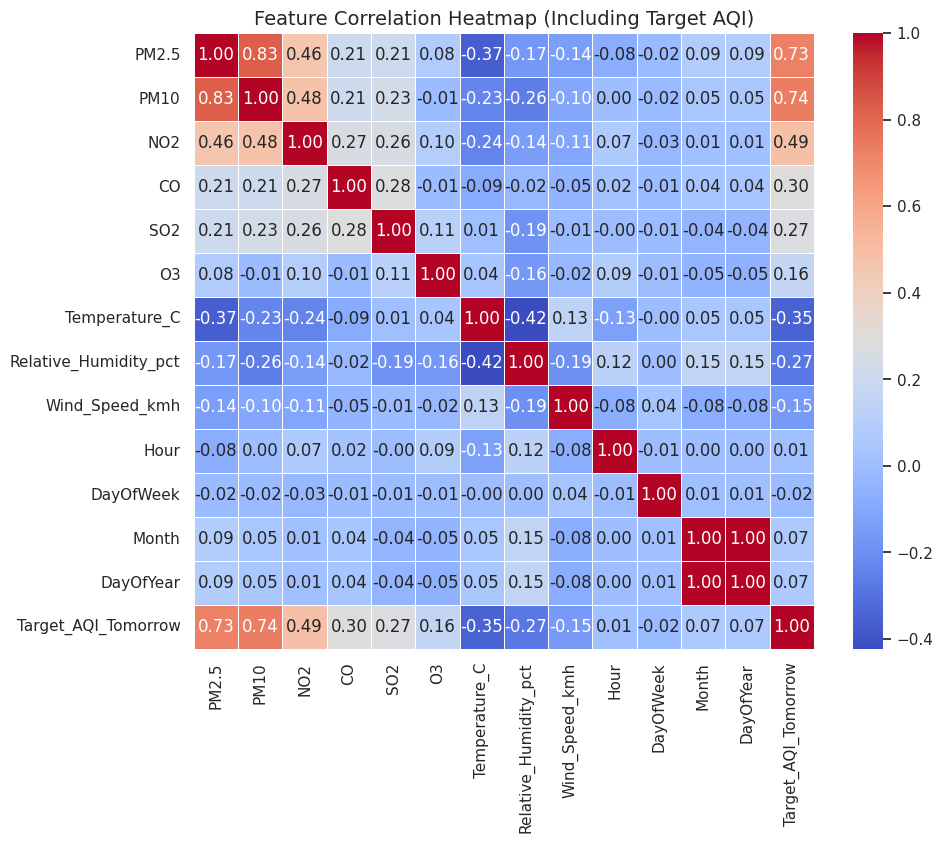

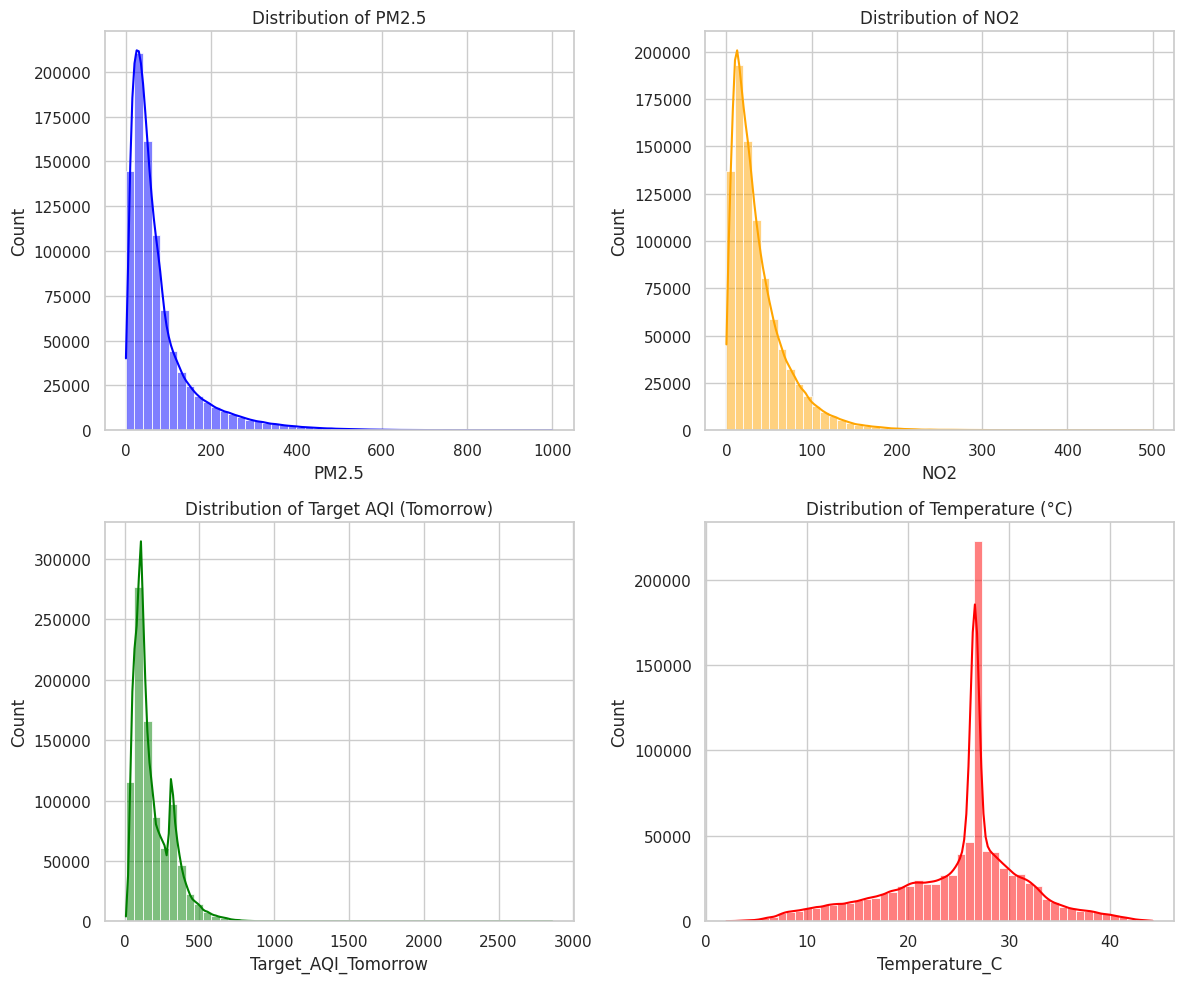

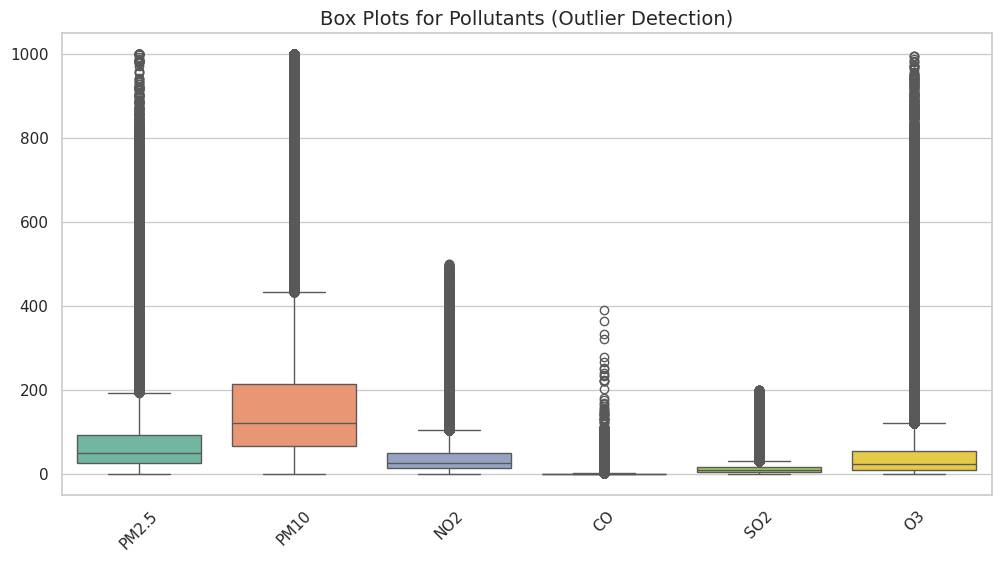

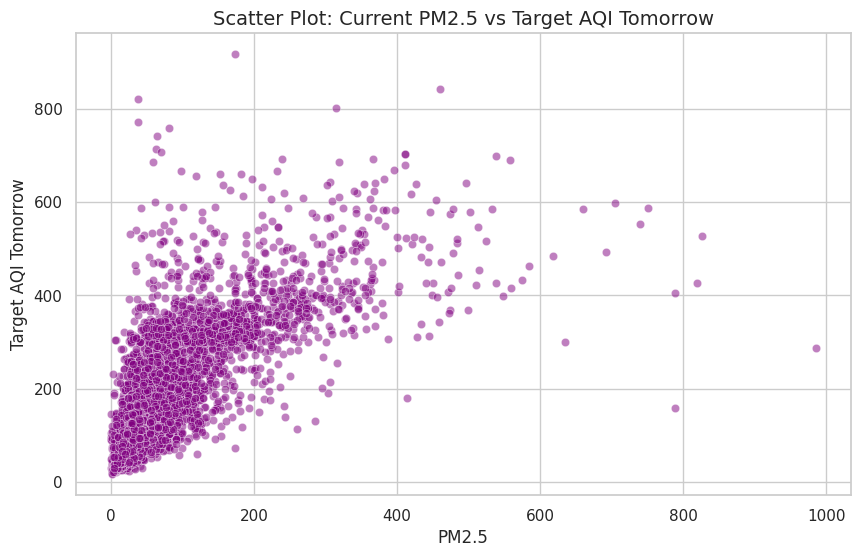

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a copy of the cleaned dataset and align it with the target series
plot_df = satellite_data.copy()
plot_df['Target_AQI_Tomorrow'] = y_train.loc[plot_df.index]

# 1. Correlation Heatmap (2D)
plt.figure(figsize=(10, 8))
numeric_df = plot_df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Including Target AQI)", fontsize=14)
plt.show()

# 2. Histograms for Key Pollutants / Target
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(plot_df['PM2.5'].dropna(), bins=50, ax=axes[0, 0], color='blue', kde=True)
axes[0, 0].set_title("Distribution of PM2.5")

sns.histplot(plot_df['NO2'].dropna(), bins=50, ax=axes[0, 1], color='orange', kde=True)
axes[0, 1].set_title("Distribution of NO2")

sns.histplot(plot_df['Target_AQI_Tomorrow'].dropna(), bins=50, ax=axes[1, 0], color='green', kde=True)
axes[1, 0].set_title("Distribution of Target AQI (Tomorrow)")

sns.histplot(plot_df['Temperature_C'].dropna(), bins=50, ax=axes[1, 1], color='red', kde=True)
axes[1, 1].set_title("Distribution of Temperature (°C)")

plt.tight_layout()
plt.show()

# 3. Box Plots to Detect Outliers
plt.figure(figsize=(12, 6))
pollutants_to_plot = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
existing_pollutants = [col for col in pollutants_to_plot if col in plot_df.columns]
sns.boxplot(data=plot_df[existing_pollutants], palette="Set2")
plt.title("Box Plots for Pollutants (Outlier Detection)", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 4. Standard 2D Scatter Plot: PM2.5 vs Target AQI Tomorrow
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df.sample(n=5000, random_state=42),
    x='PM2.5',
    y='Target_AQI_Tomorrow',
    alpha=0.5,
    color='purple'
)
plt.title("Scatter Plot: Current PM2.5 vs Target AQI Tomorrow", fontsize=14)
plt.xlabel("PM2.5")
plt.ylabel("Target AQI Tomorrow")
plt.show()

In [115]:
# 1. Calculate and display Skewness for all numerical columns
print("=== SKEWNESS REPORT ===")
print("Note: Values > +1 or < -1 indicate high skewness (long tails).")
skew_values = satellite_data.select_dtypes(include=['number']).skew().sort_values(ascending=False)
for col, skew in skew_values.items():
    print(f"{col}: {skew:.2f}")

# 2. Calculate and display Correlations with Target_AQI_Tomorrow
print("\n=== CORRELATION WITH TOMORROW'S AQI ===")
print("Note: Values closer to +1 or -1 have strong linear relationships.")

# Create temporary dataframe with target to compute correlations by aligning with y_train
temp_corr_df = satellite_data.select_dtypes(include=['number']).copy()
temp_corr_df['Target_AQI_Tomorrow'] = y_train.loc[temp_corr_df.index]

correlations = temp_corr_df.corr()['Target_AQI_Tomorrow'].sort_values(ascending=False)
for col, corr in correlations.items():
    if col != 'Target_AQI_Tomorrow':
        print(f"{col}: {corr:.2f}")

=== SKEWNESS REPORT ===
Note: Values > +1 or < -1 indicate high skewness (long tails).
CO: 36.28
O3: 4.97
SO2: 4.49
PM2.5: 2.83
NO2: 2.65
PM10: 1.98
Wind_Speed_kmh: 1.20
DayOfYear: 0.14
Month: 0.13
DayOfWeek: 0.00
Hour: -0.03
Temperature_C: -0.55
Relative_Humidity_pct: -0.79

=== CORRELATION WITH TOMORROW'S AQI ===
Note: Values closer to +1 or -1 have strong linear relationships.
PM10: 0.74
PM2.5: 0.73
NO2: 0.49
CO: 0.30
SO2: 0.27
O3: 0.16
Month: 0.07
DayOfYear: 0.07
Hour: 0.01
DayOfWeek: -0.02
Wind_Speed_kmh: -0.15
Relative_Humidity_pct: -0.27
Temperature_C: -0.35


# Test DataSet Handling

In [116]:
summary=pd.DataFrame({
    'Total Rows':len(X_test),
    'Null Rows':X_test.isnull().sum(),
    'Filled Rows':X_test.notnull().sum(),
})
summary

,Total Rows,Null Rows,Filled Rows
PM2.5,403658,16224,387434
PM10,403658,265964,137694
NO2,403658,16789,386869
CO,403658,50781,352877
SO2,403658,16629,387029
O3,403658,66413,337245
Temperature_C,403658,403658,0
Relative_Humidity_pct,403658,403658,0
Wind_Speed_kmh,403658,403658,0
Hour,403658,0,403658


# Missing Vaue Handling


In [118]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 1. Check current missing percentages
missing_pct = (X_test.isnull().sum() / len(X_test)) * 100
print("Initial Missing Data Percentage:\n", missing_pct[missing_pct > 0])

# -------------------------------------------------------------
# RULE 1: Drop columns >40% missing, EXCEPT mandatory weather columns
# -------------------------------------------------------------
mandatory_weather_cols = ['Temperature_C', 'Relative_Humidity_pct', 'Wind_Speed_kmh']

# Find columns with >40% missing, but exclude weather features from being dropped
cols_to_drop = [col for col in missing_pct[missing_pct > 40].index if col not in mandatory_weather_cols]

satellite_data = X_test.drop(columns=cols_to_drop)
print(f"\nDropped columns (>40% missing): {cols_to_drop}")
print(f"Retained mandatory weather columns despite high missingness.")

# -------------------------------------------------------------
# SPECIAL HANDLING FOR WEATHER: Impute smoothly instead of dropping rows
# -------------------------------------------------------------
for col in mandatory_weather_cols:
    if col in satellite_data.columns:
        # Forward fill and backward fill per station/time continuity
        satellite_data[col] = satellite_data[col].ffill().bfill()

        # Fallback to training set medians if the columns are still fully null
        if satellite_data[col].isnull().sum() > 0:
            train_median = X_train[col].median() if col in X_train.columns else 0.0
            satellite_data[col] = satellite_data[col].fillna(train_median)

# -------------------------------------------------------------
# RULE 2: Rows with < 5% missing -> Drop Rows (for remaining columns)
# -------------------------------------------------------------
row_threshold = satellite_data.shape[1] - int(satellite_data.shape[1] * 0.05)
satellite_data = satellite_data.dropna(thresh=row_threshold)

# -------------------------------------------------------------
# RULE 3: Fill/Impute remaining missing values (5% to 40% range)
# -------------------------------------------------------------
numeric_cols = satellite_data.select_dtypes(include=['number']).columns
categorical_cols = satellite_data.select_dtypes(include=['object']).columns

if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    satellite_data[numeric_cols] = num_imputer.fit_transform(satellite_data[numeric_cols])

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    satellite_data[categorical_cols] = cat_imputer.fit_transform(satellite_data[categorical_cols])

# 4. Verify everything is clean
print(f"\nFinal Dataset Shape: {satellite_data.shape}")
print("Total remaining nulls:", satellite_data.isnull().sum().sum())

Initial Missing Data Percentage:
 PM2.5                      4.019244
PM10                      65.888450
NO2                        4.159214
CO                        12.580204
SO2                        4.119576
O3                        16.452789
Temperature_C            100.000000
Relative_Humidity_pct    100.000000
Wind_Speed_kmh           100.000000
dtype: float64

Dropped columns (>40% missing): ['PM10']
Retained mandatory weather columns despite high missingness.

Final Dataset Shape: (276826, 12)
Total remaining nulls: 0


In [119]:
summary_test = pd.DataFrame({
    'Total Rows': len(satellite_data),
    'Null Rows': satellite_data.isnull().sum(),
    'Filled Rows': satellite_data.notnull().sum(),
})
summary_test

,Total Rows,Null Rows,Filled Rows
PM2.5,276826,0,276826
NO2,276826,0,276826
CO,276826,0,276826
SO2,276826,0,276826
O3,276826,0,276826
Temperature_C,276826,0,276826
Relative_Humidity_pct,276826,0,276826
Wind_Speed_kmh,276826,0,276826
Hour,276826,0,276826
DayOfWeek,276826,0,276826


In [ ]:
import plotly.express as px
import pandas as pd

# Ensure the target series is aligned with our cleaned features
visual_df = satellite_data.copy()
visual_df['Target_AQI_Tomorrow'] = y_test.loc[visual_df.index]

# Sample a subset for smooth 3D rendering
sample_df = visual_df.sample(n=5000, random_state=42)

fig = px.scatter_3d(
    sample_df,
    x='PM2.5',
    y='Temperature_C',
    z='Wind_Speed_kmh',
    color='Target_AQI_Tomorrow',
    color_continuous_scale='Viridis',
    opacity=0.7,
    title="3D Interactive Scatter: PM2.5 vs Temperature vs Wind Speed (Colored by Target AQI)"
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a copy of the cleaned dataset and align it with the target series
plot_df = satellite_data.copy()
plot_df['Target_AQI_Tomorrow'] = y_test.loc[plot_df.index]

# 1. Correlation Heatmap (2D)
plt.figure(figsize=(10, 8))
numeric_df = plot_df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Including Target AQI)", fontsize=14)
plt.show()

# 2. Histograms for Key Pollutants / Target
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(plot_df['PM2.5'].dropna(), bins=50, ax=axes[0, 0], color='blue', kde=True)
axes[0, 0].set_title("Distribution of PM2.5")

sns.histplot(plot_df['NO2'].dropna(), bins=50, ax=axes[0, 1], color='orange', kde=True)
axes[0, 1].set_title("Distribution of NO2")

sns.histplot(plot_df['Target_AQI_Tomorrow'].dropna(), bins=50, ax=axes[1, 0], color='green', kde=True)
axes[1, 0].set_title("Distribution of Target AQI (Tomorrow)")

sns.histplot(plot_df['Temperature_C'].dropna(), bins=50, ax=axes[1, 1], color='red', kde=True)
axes[1, 1].set_title("Distribution of Temperature (°C)")

plt.tight_layout()
plt.show()

# 3. Box Plots to Detect Outliers
plt.figure(figsize=(12, 6))
pollutants_to_plot = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
existing_pollutants = [col for col in pollutants_to_plot if col in plot_df.columns]
sns.boxplot(data=plot_df[existing_pollutants], palette="Set2")
plt.title("Box Plots for Pollutants (Outlier Detection)", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 4. Standard 2D Scatter Plot: PM2.5 vs Target AQI Tomorrow
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df.sample(n=5000, random_state=42),
    x='PM2.5',
    y='Target_AQI_Tomorrow',
    alpha=0.5,
    color='purple'
)
plt.title("Scatter Plot: Current PM2.5 vs Target AQI Tomorrow", fontsize=14)
plt.xlabel("PM2.5")
plt.ylabel("Target AQI Tomorrow")
plt.show()

In [120]:
# 1. Calculate and display Skewness for all numerical columns in preprocessed test set
print("=== SKEWNESS REPORT (TEST SET) ===")
print("Note: Values > +1 or < -1 indicate high skewness (long tails).")
skew_values_test = satellite_data.select_dtypes(include=['number']).skew().sort_values(ascending=False)
for col, skew in skew_values_test.items():
    print(f"{col}: {skew:.2f}")

# 2. Calculate and display Correlations with Target_AQI_Tomorrow
print("\n=== CORRELATION WITH TOMORROW'S AQI (TEST SET) ===")
print("Note: Values closer to +1 or -1 have strong linear relationships.")

# Create temporary dataframe with target to compute correlations by aligning with y_test
temp_corr_df_test = satellite_data.select_dtypes(include=['number']).copy()
temp_corr_df_test['Target_AQI_Tomorrow'] = y_test.loc[temp_corr_df_test.index]

correlations_test = temp_corr_df_test.corr()['Target_AQI_Tomorrow'].sort_values(ascending=False)
for col, corr in correlations_test.items():
    if col != 'Target_AQI_Tomorrow':
        print(f"{col}: {corr:.2f}")

=== SKEWNESS REPORT (TEST SET) ===
Note: Values > +1 or < -1 indicate high skewness (long tails).
CO: 15.12
SO2: 5.97
PM2.5: 5.02
NO2: 2.82
O3: 1.76
DayOfYear: 0.11
Month: 0.10
Temperature_C: 0.00
Wind_Speed_kmh: 0.00
Relative_Humidity_pct: 0.00
DayOfWeek: -0.00
Hour: -0.03

=== CORRELATION WITH TOMORROW'S AQI (TEST SET) ===
Note: Values closer to +1 or -1 have strong linear relationships.
PM2.5: 0.71
NO2: 0.39
CO: 0.25
SO2: 0.16
O3: 0.14
DayOfYear: 0.07
Month: 0.07
Hour: 0.03
DayOfWeek: -0.02
Temperature_C: nan
Relative_Humidity_pct: nan
Wind_Speed_kmh: nan


In [122]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import numpy as np

# -------------------------------------------------------------
# PREPROCESS X_TRAIN (just like we did for X_test)
# -------------------------------------------------------------
print("Preprocessing Training Set...")
# 1. Drop PM10 from train as it was dropped in test due to >40% missing
satellite_train = X_train.drop(columns=['PM10'], errors='ignore')

# 2. Impute weather features smoothly
mandatory_weather_cols = ['Temperature_C', 'Relative_Humidity_pct', 'Wind_Speed_kmh']
for col in mandatory_weather_cols:
    if col in satellite_train.columns:
        satellite_train[col] = satellite_train[col].ffill().bfill()
        if satellite_train[col].isnull().sum() > 0:
            satellite_train[col] = satellite_train[col].fillna(satellite_train[col].median())

# 3. Drop rows with < 5% missing (based on row threshold)
row_threshold = satellite_train.shape[1] - int(satellite_train.shape[1] * 0.05)
satellite_train = satellite_train.dropna(thresh=row_threshold)

# 4. Fill remaining missing values
numeric_cols = satellite_train.select_dtypes(include=['number']).columns
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    satellite_train[numeric_cols] = num_imputer.fit_transform(satellite_train[numeric_cols])

# 5. Define clean train/test feature sets and targets
y_train_clean = y_train.loc[satellite_train.index]
X_train_clean = satellite_train

y_test_clean = y_test.loc[satellite_data.index]
X_test_clean = satellite_data

print(f"Cleaned Training samples: {X_train_clean.shape[0]}")
print(f"Cleaned Testing samples: {X_test_clean.shape[0]}")

# -------------------------------------------------------------
# TRAIN AND EVALUATE MODEL
# -------------------------------------------------------------
# Train a Random Forest model on a subset of 100,000 samples for speed
sub_X_train = X_train_clean.sample(n=min(100000, len(X_train_clean)), random_state=42)
sub_y_train = y_train_clean.loc[sub_X_train.index]

print("\nTraining Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
model.fit(sub_X_train, sub_y_train)

# Predict and Evaluate
predictions = model.predict(X_test_clean)

mse = mean_squared_error(y_test_clean, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_clean, predictions)
r2 = r2_score(y_test_clean, predictions)

print("\n=== MODEL PERFORMANCE EVALUATION (TEST SET) ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Preprocessing Training Set...
Cleaned Training samples: 1064816
Cleaned Testing samples: 276826

Training Random Forest Regressor...

=== MODEL PERFORMANCE EVALUATION (TEST SET) ===
Mean Absolute Error (MAE): 46.95
Root Mean Squared Error (RMSE): 64.28
R-squared (R2) Score: 0.59
